# Day 1-2: 문제 이해 & 베이스라인 모델

**강의 시간**: 1.5시간  
**학습 목표**:
- 뉴스 토픽 분류 문제의 특성 이해
- 데이터 탐색(EDA)을 통한 인사이트 도출
- TF-IDF + Logistic Regression 베이스라인 구축
- MLflow로 첫 실전 실험 기록

**사전 요구사항**: Day 1-1 환경 설정 완료


## 🔧 0. 환경 재설정


새 노트북을 시작하므로 필요한 설정을 다시 로드합니다.

In [ ]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# 1) 폰트 파일 직접 다운로드 (런타임 재시작 불필요)
!wget -q -O NanumGothic.ttf -L "https://fonts.gstatic.com/ea/nanumgothic/v5/NanumGothic-Regular.ttf"

import matplotlib.font_manager as fm

# 폰트 파일 경로
font_path = "NanumGothic.ttf"

# 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

# Seaborn 스타일
sns.set_style('whitegrid')

print("✅ 라이브러리 로드 완료!")

In [ ]:
fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic') # 파일 저장되어있는 경로와 이름 설정
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) #폰트설정

In [ ]:
# 라이브러리 설치 (약 30초 소요)
%pip install -q dagshub 'mlflow>=2,<3'

print("✅ 라이브러리 설치 완료!")

🔥 이 부분은 수정이 필요합니다.

아래 `repo_owner`, `repo_name`을 본인의 Dagshub 정보로 채워주세요.


In [ ]:
# Dagshub & MLflow 재연동
import dagshub
import mlflow

# 🔥 본인의 정보로 수정!
repo_owner = ''  # 본인 Dagshub username
repo_name = ''  # 생성한 repository 이름

dagshub.init(
    repo_owner=repo_owner,
    repo_name=repo_name,
    mlflow=True
)

mlflow.set_experiment("day1-news-classification")

print("✅ Dagshub 연동 완료!")


## 📂 1. 데이터 로드



### 데이터 불러오기

#### Google Drive

In [ ]:
# from google.colab import drive

# # Google Drive 마운트
# drive.mount('/content/drive')

# print("\n✅ Google Drive 연결 완료!")
# print("📁 Drive 경로: /content/drive/MyDrive")

In [ ]:
# import shutil
# import os

# # Google Drive에서 복사 (Drive에 업로드했을 경우)
# # drive_data_path = '/content/drive/MyDrive/dacon_data'  # Drive에 업로드한 경로
# drive_data_path = '/content/drive/MyDrive/lectures/dl_bootcamp/day1_news_classification/data/dacon_data'  # Drive에 업로드한 경로

# # 현재 작업 폴더로 복사
# if os.path.exists(f'{drive_data_path}/train_data.csv'):
#     shutil.copy(f'{drive_data_path}/train_data.csv', './train_data.csv')
#     shutil.copy(f'{drive_data_path}/test_data.csv', './test_data.csv')
#     shutil.copy(f'{drive_data_path}/topic_dict.csv', './topic_dict.csv')
#     shutil.copy(f'{drive_data_path}/sample_submission.csv', './sample_submission.csv')
#     print("✅ Drive에서 데이터 복사 완료!")
# else:
#     print("❌ Drive에 데이터가 없습니다. 방법 1을 사용하세요.")

#### 데이터 업로드

In [ ]:
import os
import zipfile
from google.colab import files

# 1. 경로 설정
# 최종적으로 데이터가 저장될 하위 폴더 이름은 'dacon_data'로 고정합니다.
base_data_path = '/content/data'
target_path = os.path.join(base_data_path, 'dacon_data')

os.makedirs(target_path, exist_ok=True)

# 2. 파일 업로드
print("📤 업로드할 ZIP 파일을 선택해주세요 (파일명 상관없음)...")
uploaded = files.upload()

# 3. 업로드된 파일 중 ZIP 파일 자동 탐색 및 압축 해제
uploaded_zip_files = [f for f in uploaded.keys() if f.endswith('.zip')]

if uploaded_zip_files:
    # 가장 먼저 업로드된 ZIP 파일 하나를 대상으로 수행
    zip_file_name = uploaded_zip_files[0]

    print(f"\n📦 '{zip_file_name}'을(를) {target_path}에 압축 해제 중...")
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(target_path)

    print(f"✅ 압축 해제 완료: {target_path}")

    # 세션 용량 확보를 위해 업로드된 원본 zip 파일 삭제
    os.remove(zip_file_name)
else:
    print("\n⚠️ 업로드된 파일 중 ZIP 형식이 없습니다.")

# 4. 결과 확인
print(f"\n📂 {target_path} 내부 파일 목록:")
try:
    print(os.listdir(target_path))
except FileNotFoundError:
    print("폴더가 생성되지 않았습니다.")

In [ ]:
data_path = target_path

#### 데이터 불러오기

In [ ]:
# CSV 파일 로드
train_df = pd.read_csv(os.path.join(data_path, 'train_data.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'test_data.csv'))

print(f"✅ Train 데이터: {len(train_df):,}개")
print(f"✅ Test 데이터: {len(test_df):,}개")

# 처음 5개 샘플 확인
train_df.head()

### 데이터 구조 확인

In [ ]:
# 데이터 정보
print("📊 데이터 정보:")
print(train_df.info())

print("\n📊 기본 통계:")
print(train_df.describe())

In [ ]:
# 컬럼 확인
print("📋 Train 컬럼:", train_df.columns.tolist())
print("📋 Test 컬럼:", test_df.columns.tolist())

# 결측치 확인
print("\n❓ Train 결측치:")
print(train_df.isnull().sum())

print("\n❓ Test 결측치:")
print(test_df.isnull().sum())


## 📊 2. 탐색적 데이터 분석 (EDA)

### 2.1 타겟(토픽) 분포 확인

In [ ]:
# 토픽별 개수
topic_counts = train_df['topic_idx'].value_counts().sort_index()

print("📊 토픽별 분포:")
print(topic_counts)

# 토픽 이름 매핑 (실제 데이터에 맞게 수정 필요)
topic_names = {
    0: '정치',
    1: '경제',
    2: '사회',
    3: '생활/문화',
    4: '세계',
    5: 'IT/과학',
    6: '스포츠'
}

print("\n📌 토픽 이름:")
for idx, name in topic_names.items():
    count = topic_counts.get(idx, 0)
    print(f"  {idx}: {name} - {count:,}개 ({count/len(train_df)*100:.1f}%)")

In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [ ]:
# 시각화
plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Topic Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Topic Index', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ❓ 질문: 데이터가 불균형한가요? 가장 많은 토픽과 가장 적은 토픽의 비율은?

### 2.2 텍스트 길이 분석

In [ ]:
# 헤드라인 길이 계산
train_df['title_length'] = train_df['title'].str.len()

print("📏 헤드라인 길이 통계:")
print(train_df['title_length'].describe())

# 토픽별 평균 길이
print("\n📏 토픽별 평균 길이:")
avg_length_by_topic = train_df.groupby('topic_idx')['title_length'].mean().sort_values(ascending=False)
print(avg_length_by_topic)

In [ ]:
# 길이 분포 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_df['title_length'], bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.axvline(train_df['title_length'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
plt.title('제목 길이 분포', fontweight='bold')
plt.xlabel('길이 (글자 수)')
plt.ylabel('빈도')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([train_df[train_df['topic_idx']==i]['title_length'] for i in range(7)],
            labels=range(7))
plt.title('토픽별 제목 길이', fontweight='bold')
plt.xlabel('토픽 번호 (Index)')
plt.ylabel('길이 (글자 수)')

plt.tight_layout()
plt.show()

### 2.3 샘플 데이터 확인

In [ ]:
# 각 토픽별로 3개씩 샘플 확인
print("📰 각 토픽별 샘플 헤드라인:\n")

for topic_idx in range(7):
    topic_name = topic_names.get(topic_idx, f'Unknown-{topic_idx}')
    samples = train_df[train_df['topic_idx'] == topic_idx]['title'].sample(min(3, len(train_df[train_df['topic_idx'] == topic_idx]))).values

    print(f"\n🔹 {topic_idx}: {topic_name}")
    for i, sample in enumerate(samples, 1):
        print(f"  {i}. {sample}")


## 🤖 3. 베이스라인 모델: TF-IDF + Logistic Regression



### 3.1 데이터 준비

🔥 이 부분을 같이 작성해봅시다.

아래에서 **train_test_split**으로 Train/Validation을 나누어 보세요.


In [ ]:
from sklearn.model_selection import train_test_split

# Train / Validation 분리
X = train_df['title']
y = train_df['topic_idx']

X_train, X_val, y_train, y_val = # 🔥 직접 작성이 필요합니다.


### 3.2 TF-IDF Vectorization


💡 **TF-IDF란?**
- **TF (Term Frequency)**: 문서 내 단어 빈도
- **IDF (Inverse Document Frequency)**: 전체 문서에서 희귀한 정도
- 중요한 단어에 높은 가중치 부여

🔥 이 부분을 같이 작성해봅시다.

아래 셀에서 **TfidfVectorizer( )** 괄호 안 파라미터와 **X_train_tfidf**, **X_val_tfidf** 두 줄을 직접 채워보세요.
(max_features, ngram_range, analyzer 등과 Train은 fit_transform, Val은 transform만)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 변환기 생성
tfidf = # 🔥 직접 작성이 필요합니다.

# Train 데이터로 fit & transform
X_train_tfidf = # 🔥 직접 작성이 필요합니다.
X_val_tfidf = # 🔥 직접 작성이 필요합니다.

print(f"✅ TF-IDF 변환 완료!")
print(f"📊 Feature 개수: {X_train_tfidf.shape[1]:,}")
print(f"📊 Train shape: {X_train_tfidf.shape}")
print(f"📊 Val shape: {X_val_tfidf.shape}")


### 3.3 Logistic Regression 학습

🔥 이 부분을 같이 작성해봅시다.

**LogisticRegression( )** 괄호 안에 C, max_iter, random_state, n_jobs 등을 채워보세요.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 모델 생성
model = # 🔥 직접 작성이 필요합니다.

print("🏋️ 모델 학습 시작...")
model.fit(X_train_tfidf, y_train)
print("✅ 학습 완료!")


### 3.4 예측 및 평가

🔥 이 부분을 같이 작성해봅시다.

**예측**(model.predict)과 **평가 지표**(accuracy_score, f1_score with average='macro') 계산을 채워보세요.


In [ ]:
# 예측
y_train_pred = # 🔥 직접 작성이 필요합니다.
y_val_pred = # 🔥 직접 작성이 필요합니다.

# 평가 지표 계산
train_acc = # 🔥 직접 작성이 필요합니다.
val_acc = # 🔥 직접 작성이 필요합니다.

train_f1 = # 🔥 직접 작성이 필요합니다.
val_f1 = # 🔥 직접 작성이 필요합니다.

print("📊 모델 성능:")
print(f"\n  Train Accuracy: {train_acc:.4f}")
print(f"  Train F1 (Macro): {train_f1:.4f}")
print(f"\n  Val Accuracy: {val_acc:.4f}")
print(f"  Val F1 (Macro): {val_f1:.4f}")

# 목표 달성 여부
if val_f1 >= 0.80:
    print("\n🎉 목표 달성! (F1 >= 0.80)")
else:
    print(f"\n⚠️ 목표 미달성 (현재: {val_f1:.4f}, 목표: 0.80)")


### 3.5 상세 분류 리포트

In [ ]:
# 클래스별 성능
print("📋 Classification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=[topic_names[i] for i in range(7)]))

### 3.6 Confusion Matrix 시각화

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[topic_names[i] for i in range(7)],
            yticklabels=[topic_names[i] for i in range(7)])
plt.title('Confusion 매트릭스 - 베이스라인 모델', fontsize=14, fontweight='bold')
plt.ylabel('실제 레이블 (True Label)', fontsize=12)
plt.xlabel('예측 레이블 (Predicted Label)', fontsize=12)
plt.tight_layout()

# 이미지 저장 (MLflow에 업로드할 예정)
plt.savefig('confusion_matrix_baseline.png', dpi=100, bbox_inches='tight')
plt.show()

# ❓ 질문: 어떤 토픽끼리 자주 혼동되나요?


## 🔬 4. MLflow 실험 로깅



### 4.1 첫 번째 실전 실험 기록

🔥 이 부분은 수정이 필요합니다.

`run_name`을 비워두었습니다. 실험을 구분하기 쉬운 이름으로 채워보세요. (예: `baseline-tfidf-C1.0-maxfeat5000`)


In [ ]:
# MLflow에 실험 기록
with mlflow.start_run(run_name=""  # 원하는 실험 이름 입력):

    # ===== Parameters (하이퍼파라미터) =====
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 5000)
    mlflow.log_param('ngram_range', '(1,1)')
    mlflow.log_param('C', 1.0)
    mlflow.log_param('analyzer', 'char')
    mlflow.log_param('test_size', 0.2)

    # ===== Metrics (평가 지표) =====
    mlflow.log_metric('train_accuracy', train_acc)
    mlflow.log_metric('train_f1_macro', train_f1)
    mlflow.log_metric('val_accuracy', val_acc)
    mlflow.log_metric('val_f1_macro', val_f1)

    # ===== Artifacts (산출물) =====
    mlflow.log_artifact('confusion_matrix_baseline.png')

    # Classification report를 텍스트로 저장
    with open('classification_report.txt', 'w') as f:
        f.write(classification_report(y_val, y_val_pred,
                                     target_names=[topic_names[i] for i in range(7)]))
    mlflow.log_artifact('classification_report.txt')

    print("✅ MLflow 실험 기록 완료!")
    print(f"🔍 Dagshub: https://dagshub.com/YOUR_USERNAME/YOUR_REPO_NAME/experiments")

### 4.2 Dagshub UI 확인




1. Dagshub 프로젝트 페이지 이동
2. "Experiments" 탭 클릭
3. `baseline-tfidf-C1.0-maxfeat5000` 실험 확인
4. Parameters, Metrics, Artifacts 확인

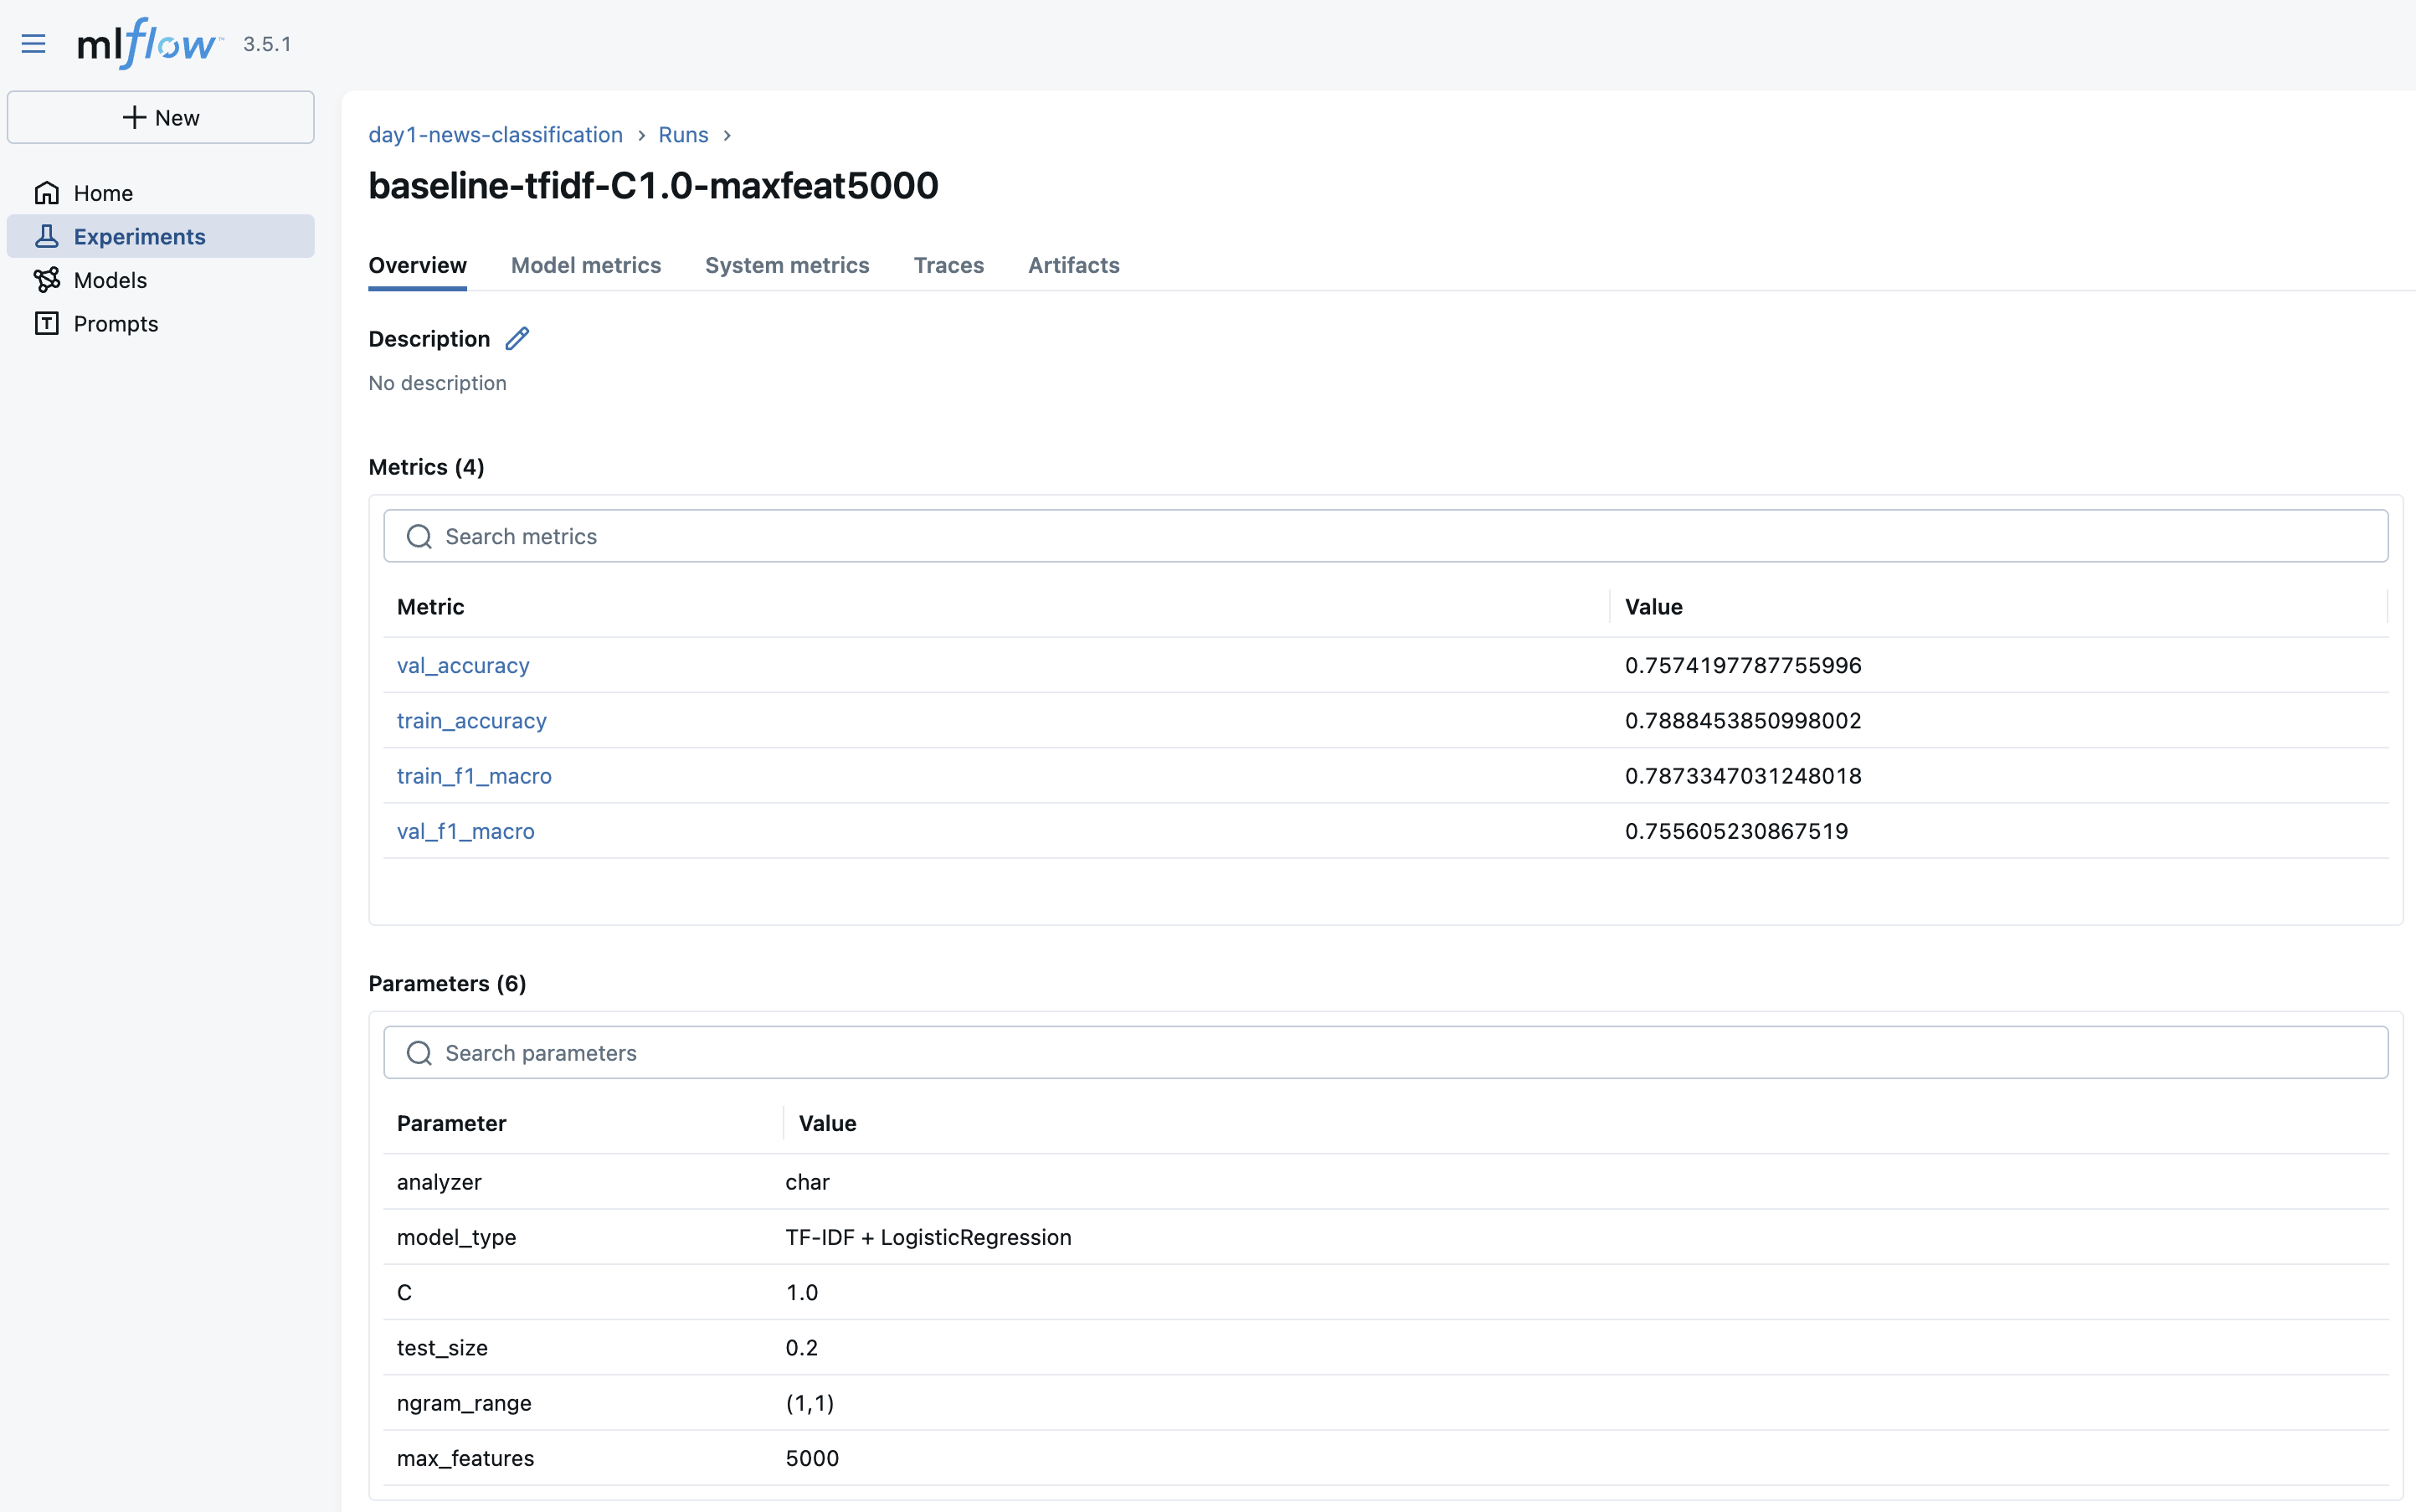

## 💡 5. 성능 개선 실험 (자유 시간)

### 실험 1: max_features 조정

In [ ]:
# 🎯 도전 과제: max_features를 바꿔서 실험해보세요!
# 힌트: 1000, 3000, 10000 등으로 변경

# TODO: 여러분이 직접 작성해보세요
# 1. TfidfVectorizer의 max_features 변경
# 2. fit_transform 재실행
# 3. 모델 학습 & 평가
# 4. MLflow 로깅 (run_name 변경!)

# 예시 코드 (주석 해제 후 수정):
# tfidf_new = TfidfVectorizer(max_features=10000, ...)
# X_train_new = tfidf_new.fit_transform(X_train)
# ...

In [ ]:
# 실험 1-1: max_features = 3000
tfidf_exp1 = TfidfVectorizer(
    max_features=3000,  # 5000 → 3000으로 축소
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.9,
    analyzer='char',
    sublinear_tf=True
)

X_train_exp1 = tfidf_exp1.fit_transform(X_train)
X_val_exp1 = tfidf_exp1.transform(X_val)

model_exp1 = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
model_exp1.fit(X_train_exp1, y_train)

y_val_pred_exp1 = model_exp1.predict(X_val_exp1)
val_f1_exp1 = f1_score(y_val, y_val_pred_exp1, average='macro')
val_acc_exp1 = accuracy_score(y_val, y_val_pred_exp1)

print(f"실험 1-1 결과:")
print(f"  Val F1: {val_f1_exp1:.4f}")
print(f"  Val Accuracy: {val_acc_exp1:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="exp1-maxfeat3000-C1.0"):
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 3000)
    mlflow.log_param('C', 1.0)
    mlflow.log_param('ngram_range', '(1,1)')

    mlflow.log_metric('val_f1_macro', val_f1_exp1)
    mlflow.log_metric('val_accuracy', val_acc_exp1)

print("✅ 실험 1-1 MLflow 로깅 완료!")

In [ ]:
# 실험 1-2: max_features = 10000
tfidf_exp2 = TfidfVectorizer(
    max_features=10000,  # 5000 → 10000으로 확대
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.9,
    analyzer='char',
    sublinear_tf=True
)

X_train_exp2 = tfidf_exp2.fit_transform(X_train)
X_val_exp2 = tfidf_exp2.transform(X_val)

model_exp2 = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
model_exp2.fit(X_train_exp2, y_train)

y_val_pred_exp2 = model_exp2.predict(X_val_exp2)
val_f1_exp2 = f1_score(y_val, y_val_pred_exp2, average='macro')
val_acc_exp2 = accuracy_score(y_val, y_val_pred_exp2)

print(f"실험 1-2 결과:")
print(f"  Val F1: {val_f1_exp2:.4f}")
print(f"  Val Accuracy: {val_acc_exp2:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="exp1-maxfeat10000-C1.0"):
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 10000)
    mlflow.log_param('C', 1.0)
    mlflow.log_param('ngram_range', '(1,1)')

    mlflow.log_metric('val_f1_macro', val_f1_exp2)
    mlflow.log_metric('val_accuracy', val_acc_exp2)

print("✅ 실험 1-2 MLflow 로깅 완료!")

### 실험 2: C 값 (Regularization) 조정

In [ ]:
# 🎯 도전 과제: C 값을 바꿔서 실험해보세요!
# 힌트: 0.1, 10.0 등으로 변경
# C가 클수록 규제 약함 (복잡한 모델), 작을수록 규제 강함 (단순한 모델)

# TODO: 여러분이 직접 작성해보세요

In [ ]:
# 실험 2-1: C = 0.1 (강한 규제)
tfidf_exp3 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.9,
    analyzer='char',
    sublinear_tf=True
)

X_train_exp3 = tfidf_exp3.fit_transform(X_train)
X_val_exp3 = tfidf_exp3.transform(X_val)

model_exp3 = LogisticRegression(C=0.1, max_iter=1000, random_state=42, n_jobs=-1)
model_exp3.fit(X_train_exp3, y_train)

y_val_pred_exp3 = model_exp3.predict(X_val_exp3)
val_f1_exp3 = f1_score(y_val, y_val_pred_exp3, average='macro')
val_acc_exp3 = accuracy_score(y_val, y_val_pred_exp3)

print(f"실험 2-1 결과:")
print(f"  Val F1: {val_f1_exp3:.4f}")
print(f"  Val Accuracy: {val_acc_exp3:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="exp2-maxfeat5000-C0.1"):
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 5000)
    mlflow.log_param('C', 0.1)
    mlflow.log_param('ngram_range', '(1,1)')

    mlflow.log_metric('val_f1_macro', val_f1_exp3)
    mlflow.log_metric('val_accuracy', val_acc_exp3)

print("✅ 실험 2-1 MLflow 로깅 완료!")

In [ ]:
# 실험 2-2: C = 10.0 (약한 규제)
tfidf_exp4 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.9,
    analyzer='char',
    sublinear_tf=True
)

X_train_exp4 = tfidf_exp4.fit_transform(X_train)
X_val_exp4 = tfidf_exp4.transform(X_val)

model_exp4 = LogisticRegression(C=10.0, max_iter=1000, random_state=42, n_jobs=-1)
model_exp4.fit(X_train_exp4, y_train)

y_val_pred_exp4 = model_exp4.predict(X_val_exp4)
val_f1_exp4 = f1_score(y_val, y_val_pred_exp4, average='macro')
val_acc_exp4 = accuracy_score(y_val, y_val_pred_exp4)

print(f"실험 2-2 결과:")
print(f"  Val F1: {val_f1_exp4:.4f}")
print(f"  Val Accuracy: {val_acc_exp4:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="exp2-maxfeat5000-C10.0"):
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 5000)
    mlflow.log_param('C', 10.0)
    mlflow.log_param('ngram_range', '(1,1)')

    mlflow.log_metric('val_f1_macro', val_f1_exp4)
    mlflow.log_metric('val_accuracy', val_acc_exp4)

print("✅ 실험 2-2 MLflow 로깅 완료!")

### 실험 3: n-gram 범위 조정

In [ ]:
# 🎯 도전 과제: ngram_range를 바꿔서 실험해보세요!
# 힌트: (1, 2)로 변경하면 unigram + bigram
# 예: "코스피 상승" → ["코", "스", "피", "상", "승", "코스", "스피", "피상", ...]

# TODO: 여러분이 직접 작성해보세요

In [ ]:
# 실험 3-1: ngram_range = (1, 2) - bigram 추가
tfidf_exp5 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # unigram + bigram
    min_df=2,
    max_df=0.9,
    analyzer='char',
    sublinear_tf=True
)

X_train_exp5 = tfidf_exp5.fit_transform(X_train)
X_val_exp5 = tfidf_exp5.transform(X_val)

model_exp5 = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
model_exp5.fit(X_train_exp5, y_train)

y_val_pred_exp5 = model_exp5.predict(X_val_exp5)
val_f1_exp5 = f1_score(y_val, y_val_pred_exp5, average='macro')
val_acc_exp5 = accuracy_score(y_val, y_val_pred_exp5)

print(f"실험 3-1 결과:")
print(f"  Val F1: {val_f1_exp5:.4f}")
print(f"  Val Accuracy: {val_acc_exp5:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="exp3-maxfeat5000-C1.0-bigram"):
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 5000)
    mlflow.log_param('C', 1.0)
    mlflow.log_param('ngram_range', '(1,2)')

    mlflow.log_metric('val_f1_macro', val_f1_exp5)
    mlflow.log_metric('val_accuracy', val_acc_exp5)

print("✅ 실험 3-1 MLflow 로깅 완료!")

In [ ]:
# 실험 3-2: ngram_range = (2, 3) - bigram + trigram
tfidf_exp6 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(2, 3),  # bigram + trigram
    min_df=2,
    max_df=0.9,
    analyzer='char',
    sublinear_tf=True
)

X_train_exp6 = tfidf_exp6.fit_transform(X_train)
X_val_exp6 = tfidf_exp6.transform(X_val)

model_exp6 = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
model_exp6.fit(X_train_exp6, y_train)

y_val_pred_exp6 = model_exp6.predict(X_val_exp6)
val_f1_exp6 = f1_score(y_val, y_val_pred_exp6, average='macro')
val_acc_exp6 = accuracy_score(y_val, y_val_pred_exp6)

print(f"실험 3-2 결과:")
print(f"  Val F1: {val_f1_exp6:.4f}")
print(f"  Val Accuracy: {val_acc_exp6:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="exp3-maxfeat5000-C1.0-trigram"):
    mlflow.log_param('model_type', 'TF-IDF + LogisticRegression')
    mlflow.log_param('max_features', 5000)
    mlflow.log_param('C', 1.0)
    mlflow.log_param('ngram_range', '(2,3)')

    mlflow.log_metric('val_f1_macro', val_f1_exp6)
    mlflow.log_metric('val_accuracy', val_acc_exp6)

print("✅ 실험 3-2 MLflow 로깅 완료!")


## 📊 6. 실험 결과 비교



### Dagshub에서 여러 실험 비교하기



1. 최소 3개 이상의 실험 완료
2. Dagshub Experiments 페이지에서 체크박스로 여러 실험 선택
3. "Compare" 버튼 클릭
4. Parallel Coordinates Plot 확인
5. 어떤 하이퍼파라미터 조합이 가장 좋은가?



### 베스트 모델 선정

In [ ]:
# 📝 메모: 베스트 모델 정보 기록
#
# Best Validation F1 Score: _______
# Best Run Name: _______
# Best Hyperparameters:
#   - max_features: _______
#   - C: _______
#   - ngram_range: _______
#
# 왜 이 조합이 좋았을까?
# _______________________________________
# _______________________________________

In [ ]:
# 모든 실험 결과 비교
experiments = {
    'Baseline (max_feat=5000, C=1.0)': val_f1,
    'Exp 1-1 (max_feat=3000, C=1.0)': val_f1_exp1,
    'Exp 1-2 (max_feat=10000, C=1.0)': val_f1_exp2,
    'Exp 2-1 (max_feat=5000, C=0.1)': val_f1_exp3,
    'Exp 2-2 (max_feat=5000, C=10.0)': val_f1_exp4,
    'Exp 3-1 (max_feat=5000, C=1.0, bigram)': val_f1_exp5,
    'Exp 3-2 (max_feat=5000, C=1.0, trigram)': val_f1_exp6,
}

print("📊 모든 실험 결과 요약:\n")
print(f"{'실험명':<45} {'F1 Score':>10}")
print("=" * 60)

for name, score in sorted(experiments.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:<45} {score:>10.4f}")

best_exp = max(experiments, key=experiments.get)
best_score = experiments[best_exp]

print("\n" + "=" * 60)
print(f"🏆 베스트 모델: {best_exp}")
print(f"🎯 Best F1 Score: {best_score:.4f}")
print("=" * 60)


## ✅ Day 1-2 완료 체크리스트



- [ ] 데이터 로드 및 기본 정보 확인
- [ ] EDA 완료 (토픽 분포, 텍스트 길이, 샘플 확인)
- [ ] Train/Validation 분리 (80/20)
- [ ] TF-IDF Vectorization 완료
- [ ] Logistic Regression 학습 및 평가
- [ ] Validation F1 Score 계산 (목표: 0.80 이상)
- [ ] Confusion Matrix 시각화
- [ ] MLflow에 베이스라인 실험 기록
- [ ] 추가 실험 최소 2개 이상 (max_features, C 등 변경)
- [ ] Dagshub UI에서 실험 비교




## 🎯 다음 단계 (Day 1-3)



**BERT/KoBERT Fine-tuning**으로 성능을 대폭 향상시킬 예정입니다!

예상 성능:
- Baseline (TF-IDF): F1 ~0.80
- **BERT**: F1 ~0.90 🚀

수고하셨습니다! 🎉